## Import all the required libraries

The libraries needed are for **Reading files, Data Manipulation, Data Cleaning, Data Transformation, Data Preprocessing, Machine Learning Models, and Model Performance Evaluation**.

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor as lgbm
from sklearn.neighbors import KNeighborsRegressor

# Performance metric
from sklearn.metrics import mean_squared_error

# Model Validation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate


# Key:
# CTD - Conductivity, Temperature and Depth
# Sal - Salinity
# Cond - Condictivity
# Press - Pressure
# ML - Machine Learning
# SV - Sound Velocity


### Open and view the CTD raw data

In [5]:
CTD_data = pd.read_csv("../Data/Raw/AT2018_phys-oce_ctd.csv")
CTD_data.head(100)


,/* DATA DESCRIPTION:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Citation:,"Ivanov, Vladimir (2019): Physical oceanography...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Abstract:,"RV ""Akademik Tryoshnikov"" left Arkhangelsk on ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,"Conductivity, Temperature, and Depth (CTD) pro...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,All Seabird sensors had been returned to the m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,This study was supported by the Russian Minist...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,31.658,32,-1.5998,-1.6004,27.025879,27.025639,34.0849,34.0853
96,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,32.645,33,-1.6141,-1.6151,27.026067,27.025766,34.1008,34.1015
97,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,33.635,34,-1.6275,-1.6281,27.025489,27.025288,34.1147,34.1151
98,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,34.626,35,-1.6436,-1.6446,27.021609,27.021186,34.1272,34.1277


<br>

The samples of the required data is shown in **row 95** downwards, which implies that that the starting point of the data is above.
Hence, there is need to inspect the data above **row 95**.

In [8]:
CTD_data.iloc[61:96, :]


,/* DATA DESCRIPTION:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
61,License:,Creative Commons Attribution 4.0 International...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,Size:,187250 data points,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,*/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,Event,Date/Time,Latitude,Longitude,Elevation [m],Depth water [m],Press [dbar],Temp [°C],Temp [°C] (Sensor 2),Cond [mS/cm],Cond [mS/cm] (Sensor 2),Sal,Sal (Sensor 2)
65,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,1.979,2,0.165,0.1772,26.584027,26.583643,31.5789,31.565
66,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,2.967,3,0.1981,0.1948,26.588512,26.586455,31.5553,31.5562
67,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,3.958,4,0.1976,0.1967,26.589017,26.58778,31.5561,31.5553
68,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,4.943,5,0.195,0.1951,26.589035,26.588031,31.5584,31.5569
69,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,5.938,6,0.1837,0.1847,26.589799,26.588741,31.5708,31.5683
70,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,6.926,7,0.1865,0.1727,26.589737,26.588478,31.5671,31.5802


The snippet of the data frame above shows the starting point of the data (**row 64**).
Hence, we will continue from here.

In [10]:
CTD_data = pd.read_csv("../Data/Raw/AT2018_phys-oce_ctd.csv", header = 65)
CTD_data.head()


,Event,Date/Time,Latitude,Longitude,Elevation [m],Depth water [m],Press [dbar],Temp [°C],Temp [°C] (Sensor 2),Cond [mS/cm],Cond [mS/cm] (Sensor 2),Sal,Sal (Sensor 2)
0,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,1.979,2,0.1650,0.1772,26.584027,26.583643,31.5789,31.5650
1,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,2.967,3,0.1981,0.1948,26.588512,26.586455,31.5553,31.5562
2,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,3.958,4,0.1976,0.1967,26.589017,26.587780,31.5561,31.5553
3,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,4.943,5,0.1950,0.1951,26.589035,26.588031,31.5584,31.5569
4,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,5.938,6,0.1837,0.1847,26.589799,26.588741,31.5708,31.5683


<br>


## Exploratory Data Analysis (EDA)
***

The column headers and data within the dataframe look okay. However, there is need to separate "**Date**" from "**Time**" for easy understanding of the dataset.

### Split the "Date/Time" column into "Date" and "Time" respectively

In [15]:
CTD_data["Formatted_Date"] = CTD_data["Date/Time"].str.split("T")

CTD_data["Date"], CTD_data["Time"] = CTD_data["Formatted_Date"].apply(lambda x: x[0]), CTD_data["Formatted_Date"].apply(lambda x: x[1])

CTD_data.head()


,Event,Date/Time,Latitude,Longitude,Elevation [m],Depth water [m],Press [dbar],Temp [°C],Temp [°C] (Sensor 2),Cond [mS/cm],Cond [mS/cm] (Sensor 2),Sal,Sal (Sensor 2),Formatted_Date,Date,Time
0,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,1.979,2,0.1650,0.1772,26.584027,26.583643,31.5789,31.5650,"[2018-08-22, 09:11:00]",2018-08-22,09:11:00
1,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,2.967,3,0.1981,0.1948,26.588512,26.586455,31.5553,31.5562,"[2018-08-22, 09:11:00]",2018-08-22,09:11:00
2,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,3.958,4,0.1976,0.1967,26.589017,26.587780,31.5561,31.5553,"[2018-08-22, 09:11:00]",2018-08-22,09:11:00
3,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,4.943,5,0.1950,0.1951,26.589035,26.588031,31.5584,31.5569,"[2018-08-22, 09:11:00]",2018-08-22,09:11:00
4,AT18_002-02,2018-08-22T09:11:00,82.389,95.2688,-2844,5.938,6,0.1837,0.1847,26.589799,26.588741,31.5708,31.5683,"[2018-08-22, 09:11:00]",2018-08-22,09:11:00


### Drop some columns and rearrange the others in the dataframe

In [17]:
# In the CTD file, 2 sensors within the instrument acquired the Temperature, Conductivity and Salinity data. 
# For the purpose of this project, the focus will only be on sensor 1.

CTD_data.drop(columns = ["Event", "Temp [°C] (Sensor 2)", "Cond [mS/cm] (Sensor 2)", "Sal (Sensor 2)", "Formatted_Date"], inplace = True)

new_order = ["Date", "Time", "Latitude", "Longitude", "Elevation [m]", "Depth water [m]", "Press [dbar]", "Temp [°C]", 
             "Cond [mS/cm]", "Sal"] 
CTD_data = CTD_data[new_order]

CTD_data.head()


,Date,Time,Latitude,Longitude,Elevation [m],Depth water [m],Press [dbar],Temp [°C],Cond [mS/cm],Sal
0,2018-08-22,09:11:00,82.389,95.2688,-2844,1.979,2,0.1650,26.584027,31.5789
1,2018-08-22,09:11:00,82.389,95.2688,-2844,2.967,3,0.1981,26.588512,31.5553
2,2018-08-22,09:11:00,82.389,95.2688,-2844,3.958,4,0.1976,26.589017,31.5561
3,2018-08-22,09:11:00,82.389,95.2688,-2844,4.943,5,0.1950,26.589035,31.5584
4,2018-08-22,09:11:00,82.389,95.2688,-2844,5.938,6,0.1837,26.589799,31.5708


### Check for any missing data

In [19]:
CTD_data.isna().sum()


Date               0
Time               0
Latitude           0
Longitude          0
Elevation [m]      0
Depth water [m]    0
Press [dbar]       0
Temp [°C]          0
Cond [mS/cm]       0
Sal                0
dtype: int64

### Export the cleaned CTD Data

In [21]:
CTD_data.to_csv("../Data/Processed/01_Cleaned CTD data.csv", index = False)


<br>

## Evaluation of Sound Velocity

### Specify the function to compute the Sound Velocity

The Sound Velocity of seawater will be computed by using the **UNESCO formula** - **Chen-Millero formula (1977)**.

In [26]:
def SV_UNESCO (S,T,P):
    # c(S,T,P) = Cw(T) + A(T,P)S + B(T,P)S^{3/2} + D(T,P)S^{2}

    
    Cw =  1402.388 + (5.03830*T) - (0.058109*T**2) + (0.0003343*T**3) - (0.00000147797*T**4) + (0.000000003146*T**5)

    # Pressure corrections  
    A = 1.389 - (1.262e-2*T) + (7.164e-5*T**2) + (2.006e-6*T**3) - (3.21e-8*T**4)
    B = (9.4742e-5) - (1.2580e-5*T) - (6.4885e-8*T**2) + (1.0160e-9*T**3) - (3.21e-8*T**4)
    C = (1.727e-3) + (7.9836e-6*T)
    Cp = A*S + B*(S*1.5) + C*(S**2)

        # Salinity corrections  
    A = 1.389 - (1.262e-2*T) + (7.164e-5*T**2) + (2.006e-6*T**3) - (3.21e-8*T**4)
    B = (9.4742e-5) - (1.2580e-5*T) - (6.4885e-8*T**2) + (1.0160e-9*T**3) - (3.21e-8*T**4)
    C = (1.727e-3) + (7.9836e-6*T)
    Cs = A*S + B*(S*1.5) + C*(S**2)

    return Cw + Cs + Cp

    # where:
    # S - Salinity
    # T - Temperature
    # P - Pressure
    # Cw - Sound Velocity in pure water
    # A - Linear salinity effect
    # B - Non-linear salinity effect
    # D - Quadratic salinity effect
    # Cp - Pressure correction
    # Cs - Salinity correction


### Compute the Sound Velocity and save it in the dataframe

In [28]:
CTD_data["Sound Velocity_Chen-Millero"] = SV_UNESCO(CTD_data["Sal"], CTD_data["Temp [°C]"], CTD_data["Press [dbar]"])

CTD_data.head()


,Date,Time,Latitude,Longitude,Elevation [m],Depth water [m],Press [dbar],Temp [°C],Cond [mS/cm],Sal,Sound Velocity_Chen-Millero
0,2018-08-22,09:11:00,82.389,95.2688,-2844,1.979,2,0.1650,26.584027,31.5789,1494.268361
1,2018-08-22,09:11:00,82.389,95.2688,-2844,2.967,3,0.1981,26.588512,31.5553,1494.337991
2,2018-08-22,09:11:00,82.389,95.2688,-2844,3.958,4,0.1976,26.589017,31.5561,1494.338267
3,2018-08-22,09:11:00,82.389,95.2688,-2844,4.943,5,0.1950,26.589035,31.5584,1494.334135
4,2018-08-22,09:11:00,82.389,95.2688,-2844,5.938,6,0.1837,26.589799,31.5708,1494.323365


<br>

### View the Descriptive Statistics of the dataframe and other information

In [31]:
CTD_data.info()                                       # Descriptive information about the dataset

print("\n")                                           #Introduce an empty line

print("CTD_data Shape: ", CTD_data.shape)             # Number of observations and features

print("\n")                                           # Introduce an empty line

CTD_data.describe()                                   # Descriptive Statistics


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26750 entries, 0 to 26749
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         26750 non-null  object 
 1   Time                         26750 non-null  object 
 2   Latitude                     26750 non-null  float64
 3   Longitude                    26750 non-null  float64
 4   Elevation [m]                26750 non-null  int64  
 5   Depth water [m]              26750 non-null  float64
 6   Press [dbar]                 26750 non-null  int64  
 7   Temp [°C]                    26750 non-null  float64
 8   Cond [mS/cm]                 26750 non-null  float64
 9   Sal                          26750 non-null  float64
 10  Sound Velocity_Chen-Millero  26750 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 2.2+ MB


CTD_data Shape:  (26750, 11)




,Latitude,Longitude,Elevation [m],Depth water [m],Press [dbar],Temp [°C],Cond [mS/cm],Sal,Sound Velocity_Chen-Millero
count,26750.000000,26750.000000,26750.000000,26750.000000,26750.000000,26750.000000,26750.000000,26750.000000,26750.000000
mean,80.660903,102.730917,-1802.651514,815.633424,827.282430,0.102869,29.280125,34.715799,1503.376875
std,1.976608,9.669595,929.054922,722.679445,734.570527,1.034874,0.974188,0.658998,4.578809
min,75.991700,94.377200,-3023.000000,0.954000,1.000000,-1.818300,24.100391,25.724400,1488.027246
25%,78.732800,94.881200,-2844.000000,217.571000,220.000000,-0.636675,29.068583,34.820700,1500.803379
50%,81.959800,95.542800,-2005.000000,608.600500,616.000000,-0.202550,29.284119,34.889600,1502.365569
75%,82.389000,112.859300,-1045.000000,1246.768000,1264.000000,0.644175,29.737219,34.913100,1505.912609
max,82.581000,126.006700,-40.000000,3009.494000,3064.000000,5.735600,31.272815,34.951500,1513.966788


### Export the CTD Data (with Chen-Millero Sound Velocity values)

In [33]:
CTD_data.to_csv("../Data/Processed/02_CTD data with Sound Velocity (Chen-Millero).csv", index = False)


<br>
<br>

## DATA VISUALIZATION 1

### Temperature vs Sound Velocity

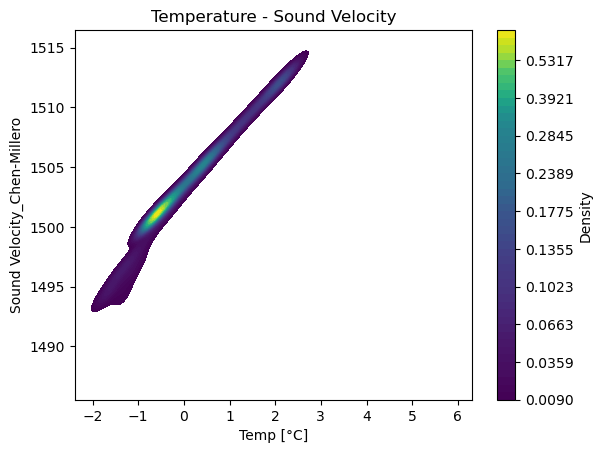

In [37]:
ax = sns.kdeplot(
    x = CTD_data['Temp [°C]'],
    y = CTD_data['Sound Velocity_Chen-Millero'],
    fill=True,
    cmap="viridis",
    levels=50,
    label = "Density",
 )

# Add color bar and title
plt.colorbar(ax.collections[0], label="Density")
plt.title("Temperature - Sound Velocity")

# Save the plot 
plt.savefig('../Data/Processed/Charts/Temperature vs Sound Velocity.png')

# Show the plot
plt.show()


**Intrepretation**: The represenation above is a KDEplot, showing the probability density distribution of the variables.

The plot shows the region between **1493 - 1498m/s** with deeper shades of purple colour indicating lower temperature,
**1499 - 1507m/s**  with green-yellowish colour showcasing highest temperature and **1508 - 1515m/s** with light purple 
colour representing moderate temperature.

### Pressure vs Sound Velocity

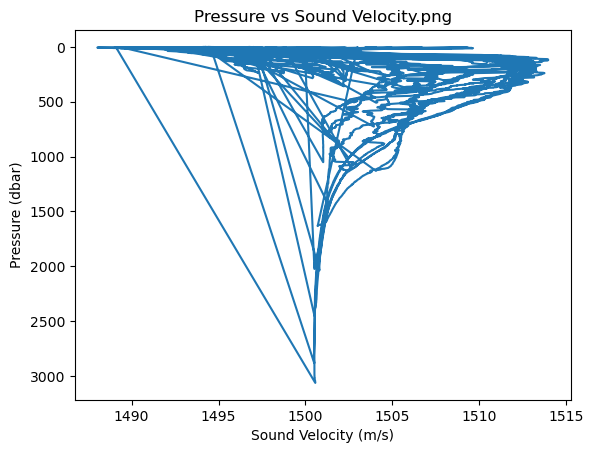

In [40]:
plt.plot(CTD_data['Sound Velocity_Chen-Millero'], CTD_data['Press [dbar]'])
plt.gca().invert_yaxis()           # Get the current axis and invert the y-axis         

# Add labels
plt.xlabel("Sound Velocity (m/s)")
plt.ylabel("Pressure (dbar)")

# Add title to the plot
plt.title('Pressure vs Sound Velocity.png')

# Save the plot 
plt.savefig("../Data/Processed/Charts/Pressure - Sound Velocity")


**Interpretation**: The plot shows that pressure increases donwards as the CTD descends to the seabed, with variations in the sound velocity (**1485 - 1514m/s**) between **0 - 1000dbar**.

Beyond 1000bar, the sound velocity maintained a fairly constant value of **1501m/s** with few spikes in the readings.

### Salinity vs Sound Velocity

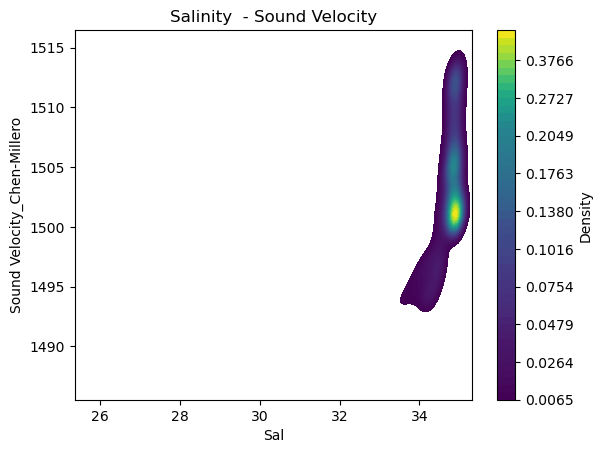

In [43]:
ax = sns.kdeplot(
    x = CTD_data['Sal'],
    y = CTD_data['Sound Velocity_Chen-Millero'],
    fill=True,
    cmap="viridis",
    levels=50,
    label = "Density",
 )

# Add color bar and title
plt.colorbar(ax.collections[0], label="Density")
plt.title("Salinity  - Sound Velocity")

# Save the plot 
plt.savefig('../Data/Processed/Charts/Salinity vs Sound Velocity.png')

# Show the plot
plt.show()


**Interpretation**: The plot showcases low salinity between **1497 - 1498m/s**, high salinity at **1500 - 1508m/s** and moderate salinity between **1508 - 1514m/s**.

<br>
<br>

## MACHINE LEARNING ALGORITHMS

### Specify the training (X) and target data (y)

In [48]:
X = CTD_data[["Sal", "Temp [°C]", "Press [dbar]"]]
y = CTD_data["Sound Velocity_Chen-Millero"]


### Initiate train_test_split and scale the features

In [50]:
# Define the train and test data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = 42, test_size = 0.25)


### Scale the features

In [52]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


***

## RANDOMFOREST MODEL

### Instantiate the  model and fit on the training data

In [56]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)

rf.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

### Predict the test data

In [58]:
y_pred_rf = rf.predict(X_test_scaled)          # Predict the SV of the test data => X_test_scaled


### Predict the Sound Velocity for  the entire dataset

In [60]:
X_full_scaled = scaler.transform(X)
y_pred_full = rf.predict(X_full_scaled)     # Predict the SV of the entire dataset => X_full_scaled


CTD_data["SV_RF"] = y_pred_full


### Evaluate the Perfromance metric of the model

The metric calculated is the Root Mean Squared Error (RMSE) of the RF model.

In [63]:
RMSE_RF = np.sqrt(mean_squared_error(y_pred_rf, y_test))
print(f"The Root mean Squared Error (RMSE) of the RF model : {RMSE_RF:.3f}m/s")


The Root mean Squared Error (RMSE) of the RF model : 0.127m/s


### Evaluate the Model Generalization

In [65]:
cv_results = cross_validate(rf, X, y, cv = 5, return_train_score = True)
scores_rf = cv_results["test_score"]

print(f"The mean cross-validation accuracy is: {scores_rf.mean():.3f} ± {scores_rf.std():.3f}")


The mean cross-validation accuracy is: 0.986 ± 0.025


***

## XGBOOST

### Instantiate the model

In [69]:
xgb_model = xgb.XGBRegressor(n_estimators = 500, random_state = 42)


### Fit the Model on the train data

In [71]:
xgb_model.fit(X_train_scaled, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

### Predict the test data

In [73]:
y_pred_xgb = xgb_model.predict(X_test_scaled)


### Predict the Sound Velocity for the entire dataset¶

In [75]:
X_scaled_fully = scaler.transform(X)
total_dataset = xgb_model.predict(X_scaled_fully)       # Predict the SV of the entire dataset => X_full_scaled

CTD_data["SV_XGB"] = total_dataset


### Evaluate the Perfromance metric of the model

In [77]:
RMSE_XGB = mean_squared_error(y_pred_xgb, y_test)
print(f" The RMSE of the XGB model is {RMSE_XGB:.3f}m/s")


 The RMSE of the XGB model is 0.071m/s


### Evaluate the Model Generalization

In [79]:
# This was done to remove the characters in the column headers, which affect the XGB model
X_prime = X.rename(columns=lambda c: c.replace('[','') .replace(']','') .replace('°',''))   


In [80]:
cv_results = cross_validate(xgb_model, X_prime, y, cv = 5, return_train_score = True)
scores_xgb = cv_results["test_score"]

print(f"The mean cross-validation accuracy is: {scores_xgb.mean():.3f} ± {scores_xgb.std():.3f}")


The mean cross-validation accuracy is: 0.981 ± 0.035


***

## LightGBM

### Instantiate the model

In [84]:
lgbm_model = lgbm(
    learning_rate = 0.05, objective = "regression", n_estimators = 1000, max_depth = 5, num_leaves=256, random_state = 42,  verbose=-1)


### Fit the model on the train data (X_train, y_train)

In [86]:
lgbm_model.fit(X_train_scaled, y_train)


LGBMRegressor(learning_rate=0.05, max_depth=5, n_estimators=1000,
              num_leaves=256, objective='regression', random_state=42,
              verbose=-1)

### Predict the test data

In [88]:
y_pred_lgbm = lgbm_model.predict(X_test_scaled)


### Predict the Sound Velocity for the entire dataset

In [90]:
X_scaled_fully = scaler.transform(X)
all_dataset = lgbm_model.predict(X_scaled_fully)          # Predict the SV of the entire dataset => X_full_scaled

CTD_data["SV_LightGBM"] = all_dataset


### Evaluate the performance metric

In [92]:
RMSE_LightGBM = mean_squared_error(y_pred_lgbm, y_test)
print(f"The RMSE of the LightGBM model is: {RMSE_LightGBM:.3f}m/s")


The RMSE of the LightGBM model is: 0.068m/s


### Evaluate the Model Generalization

In [94]:
cv_results = cross_validate(lgbm_model, X_prime, y, cv = 5, return_train_score = True)
scores_lGBM = cv_results["test_score"]

print(f"The mean cross-validation accuracy is: {scores_lGBM.mean():.3f} ± {scores_lGBM.std():.3f}")


The mean cross-validation accuracy is: 0.979 ± 0.040


***

## KNN

### Instantiate the model

In [98]:
knn_model = KNeighborsRegressor(n_neighbors  = 5)


### Fit the model on the train data (X_train, y_train)

In [100]:
knn_model.fit(X_train_scaled, y_train)


KNeighborsRegressor()

### Predict the test data

In [102]:
y_pred_knn = knn_model.predict(X_test_scaled)


### Predict the Sound Velocity for the entire dataset

In [104]:
X_scaled_fully = scaler.transform(X)
entire_dataset = knn_model.predict(X_scaled_fully)             # Predict the SV of the entire dataset => X_full_scaled

CTD_data["SV_KNN"] = entire_dataset


### Evaluate the Performance Metric

In [106]:
RMSE_KNN = mean_squared_error(y_pred_knn, y_test)
print(f"The RMSE of the LightGBM model is: {RMSE_KNN:.3f}m/s")


The RMSE of the LightGBM model is: 0.007m/s


### Evaluate the Model Generalization

In [108]:
cv_results = cross_validate(knn_model, X, y, cv = 5, return_train_score = True)
scores_knn = cv_results["test_score"]

print(f"The mean cross-validation accuracy is: {scores_knn.mean():.3f} ± {scores_knn.std():.3f}")


The mean cross-validation accuracy is: 0.941 ± 0.042


<br>
<br>

## DATA VISUALIZATION 2

### RandomForest Model Prediction (y_pred) vs y_test

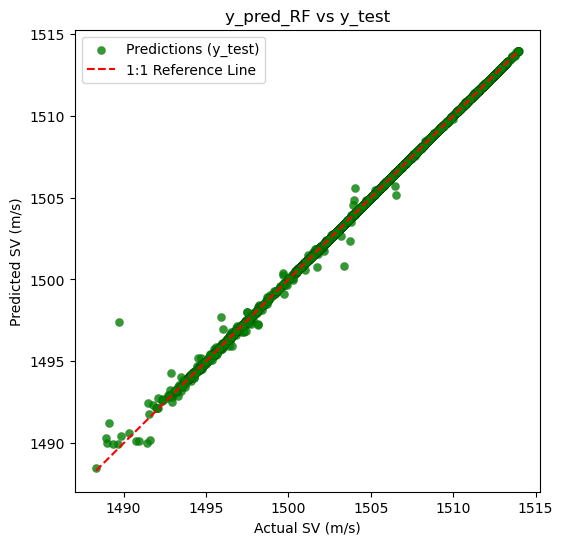

In [112]:
# Specify the dimension of the plot
plt.figure(figsize=(6, 6))

# Plot the sound velocity values (actual vs predicted)
plt.scatter(y_test, y_pred_rf, alpha = 0.8, c = "green", edgecolor = "black", linewidth = 0.1, label = "Predictions (y_test)")

# Specify the min and max values of the actual sound velocities & plot the 1:1  reference line
sv_min = y_test.min()
sv_max = y_test.max()
plt.plot([sv_min, sv_max], [sv_min, sv_max],'r--', label="1:1 Reference Line")

# Add labels
plt.xlabel("Actual SV (m/s)")
plt.ylabel("Predicted SV (m/s)")

# Add legend and title
plt.legend()
plt.title("y_pred_RF vs y_test")

# Save the Plot
plt.savefig("../Results/Charts/RF Predicted_y vs y_test.png")


### XGBoost Model Prediction (y_pred) vs y_test

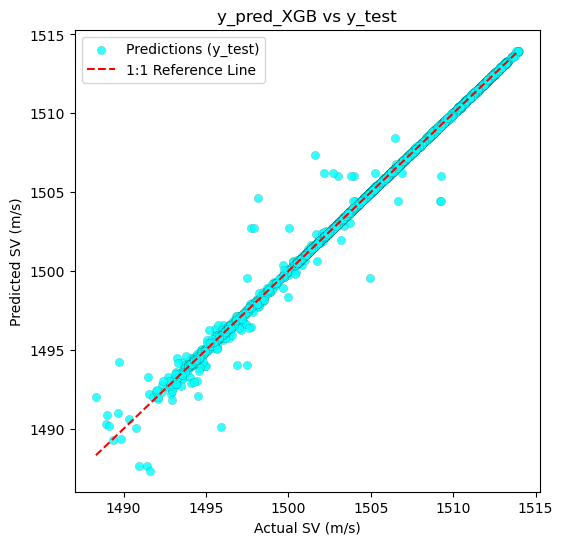

In [114]:
# Specify the dimension of the plot
plt.figure(figsize=(6, 6))

# Plot the sound velocity values (actual vs predicted)
plt.scatter(y_test, y_pred_xgb, alpha = 0.8, c = "cyan", edgecolor = "black", linewidth = 0.1, label = "Predictions (y_test)")

# Specify the min and max values of the actual sound velocities & plot the 1:1  reference line
sv_min = min(y_test.min(), y_pred_knn.min())
sv_max = max(y_test.max(), y_pred_knn.max())
plt.plot([sv_min, sv_max], [sv_min, sv_max],'r--', label="1:1 Reference Line")

# Addd labels
plt.xlabel("Actual SV (m/s)")
plt.ylabel("Predicted SV (m/s)")

# Add legend and title
plt.legend()
plt.title("y_pred_XGB vs y_test")

# Save the Plot
plt.savefig("../Results/Charts/XGBoost Predicted_y vs y_test.png")


## LightGBM Model Predicition (y_pred) vs y_test

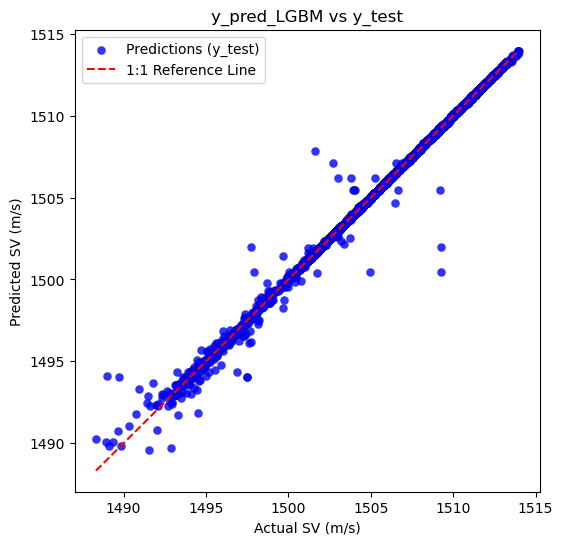

In [116]:
# Specify the dimension of the plot
plt.figure(figsize=(6, 6))

# Plot the sound velocity values (actual vs predicted)
plt.scatter(y_test, y_pred_lgbm, alpha = 0.8, c = "blue", edgecolor = "black", linewidth = 0.1, label = "Predictions (y_test)")

# Specify the min and max values of the actual sound velocities & plot the 1:1  reference line
sv_min = min(y_test.min(), y_pred_knn.min())
sv_max = max(y_test.max(), y_pred_knn.max())
plt.plot([sv_min, sv_max], [sv_min, sv_max],'r--', label="1:1 Reference Line")

# Add labels
plt.xlabel("Actual SV (m/s)")
plt.ylabel("Predicted SV (m/s)")

# Add legend and title
plt.legend()
plt.title("y_pred_LGBM vs y_test")

# Save the Plot
plt.savefig("../Results/Charts/LGBM Predicted_y vs y_test.png")


## KNN Model Predicition (y_pred) vs y_test

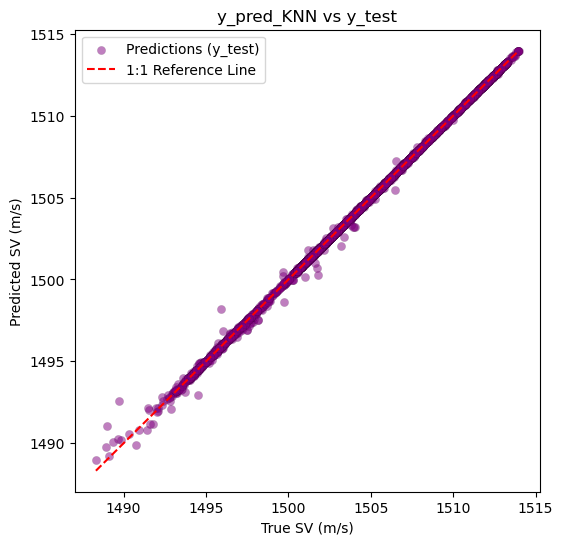

In [118]:
# Specify the dimension of the plot
plt.figure(figsize=(6, 6))

# Plot the sound velocity values (actual vs predicted)
plt.scatter(y_test, y_pred_knn, alpha = 0.5, c = "purple", edgecolor = "black", linewidth = 0.1, label = "Predictions (y_test)")

# Specify the min and max values of the actual sound velocities & plot the 1:1  reference line
sv_min = min(y_test.min(), y_pred_knn.min())
sv_max = max(y_test.max(), y_pred_knn.max())
plt.plot([sv_min, sv_max], [sv_min, sv_max],'r--', label="1:1 Reference Line")

# Add labels
plt.xlabel("True SV (m/s)")
plt.ylabel("Predicted SV (m/s)")

# Add legend and title
plt.legend()
plt.title("y_pred_KNN vs y_test")

# Save the Plot
plt.savefig("../Results/Charts/KNN Predicted_y vs y_test.png")


**Interpretation**: The charts show the graphical representation of the **ML-predicted sound velocity values  (y_pred)** and the **actual test values (y_test)** in relationship to the 1:1 Reference Line.

The models (**RF, XGBoost and LightGBM**) showed uniform distribution of points across the 1:1 Reference line while the **KNN** scatter points are not evenly distributed (few points above the reference line and more below).

The RandomForest Model shows the lowest distance of the points from the reference line (prediction error), followed by LightGBM, XGBoost and the KNN.


### Comparison of Model Performance Metric

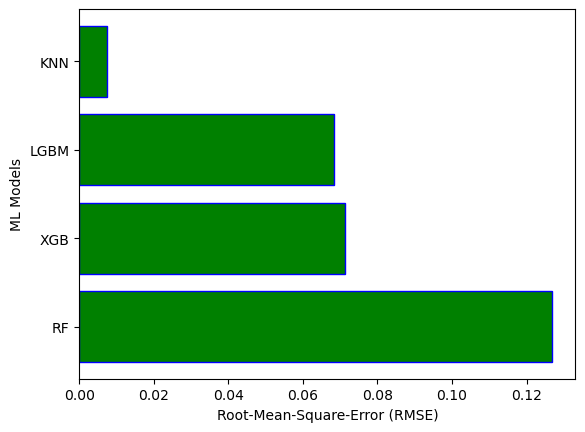

In [121]:
models_used = ['RF', 'XGB', 'LGBM', 'KNN']
rmse = [RMSE_RF, RMSE_XGB, RMSE_LightGBM, RMSE_KNN]

# Plot the barchart
plt.barh(models_used, rmse, color = "green", edgecolor = "blue", lw = 1)

# Add labels
plt.xlabel("Root-Mean-Square-Error (RMSE)")
plt.ylabel("ML Models")

# Save the chart
plt.savefig("../Results/Charts/Performance Metric of the Models.png")


<br>
<br>

# RESULT ANALYSIS
***

###  Comparison  of the Sound Velocity values for the entire dataset: Chen-Millero formula vs ML models 

In [125]:
Combined_SV = pd.DataFrame({
    
    "SV_Chen-Millero": CTD_data["Sound Velocity_Chen-Millero"],
    "SV_RF": CTD_data["SV_RF"],
    "SV_XGB": CTD_data["SV_XGB"],
    "SV_lightGBM": CTD_data["SV_LightGBM"],
    "SV_KNN": CTD_data["SV_KNN"]
})

Combined_SV


,SV_Chen-Millero,SV_RF,SV_XGB,SV_lightGBM,SV_KNN
0,1494.268361,1494.297810,1494.260864,1494.309672,1494.317657
1,1494.337991,1494.400523,1494.337402,1494.346526,1494.331583
2,1494.338267,1494.368790,1494.337402,1494.346526,1494.331583
3,1494.334135,1494.344150,1494.325195,1494.346526,1494.331583
4,1494.323365,1494.312153,1494.332642,1494.265216,1494.331583
...,...,...,...,...,...
26745,1493.647413,1493.635897,1493.563232,1493.556771,1493.608554
26746,1493.659862,1493.664451,1493.688477,1493.099212,1493.701584
26747,1493.695694,1493.705839,1493.688477,1493.912144,1493.675593
26748,1493.711754,1493.729690,1493.673096,1493.912144,1493.675593


### Export the Combined Results

In [127]:
Combined_SV.to_csv("../Results/01_Computed and ML-Predicted Sound Velocities.csv", index = False)


<br>
<br>

### Model Performance Evaluation (RMSE & Cross_validation)

In [130]:
# Compare the root-mean-squared-error (RMSE) and cross validation between the ML models
a = f"{scores_rf.mean():.3f} ± {scores_rf.std():.3f}"
b = f"{scores_xgb.mean():.3f} ± {scores_xgb.std():.3f}"
c = f"{scores_lGBM.mean():.3f} ± {scores_lGBM.std():.3f}"
d = f"{scores_knn.mean():.3f} ± {scores_knn.std():.3f}"

aggregate = pd.DataFrame({
    "RandomForest" : [round(RMSE_RF,3), a],
    "XGBoost" : [round(RMSE_XGB,3), b],
    "LightGBM" : [round(RMSE_LightGBM,3), c],
    "KNN" : [round(RMSE_KNN,3), d]
}, index = ["Root-Mean-Square-Error", "Cross_Validation"])

aggregate


,RandomForest,XGBoost,LightGBM,KNN
Root-Mean-Square-Error,0.127,0.071,0.068,0.007
Cross_Validation,0.986 ± 0.025,0.981 ± 0.035,0.979 ± 0.040,0.941 ± 0.042


**Interpretation**: The rmse of the KNN model show near-perfect values, with the lowest cross validation (cv ) value. This implies there's more information to it. 

The low cv score implies that  the KNN model will not generalize well on unseen data. KNN did not learn the training data, it operates on an interpolation-based nature (considering the distance between closest points) and memorizes the data. This led to the near-zero rmse value.

### Export the Performance Metric of models

In [133]:
aggregate.to_csv("../Results/02_Model Performance Evaluation.csv", index = True)


<br>

## Conclusion

The CTD data were extracted and the Sound velocity was computed using the ***UNESCO equation (Chen-Millero formula)**. Thereafter, the 
**Machine Learning models (RandomForest, XGboost, LightGBM, and KNN)** were applied to predict the sound velocity (inputs: Temperature, 
Salinity, Pressure), and the model performance evaluation (Root-Mean-Squared-Error & Cross Validation) were computed.

Based on model performance, **RandomForest >> XGBoost >> LightGBM>>KNN.**


<br>